*Data From Kaggle:* kaggle.com/datasets/imakash3011/customer-personality-analysis

Factor Analysis (FA) is a statistical technique used to identify hidden (latent) factors that explain the patterns of correlations among observed variables.
Think of it as discovering the underlying causes behind many related measurements.

In this section, we focused on the core mechanics of Factor Analysis, specifically how to decide and evaluate factors.

In real datasets, many variables are correlated.
Several variables often measure the same underlying concept.
Factor Analysis helps to:
- Reduce dimensionality
- Simplify interpretation
- Group related variables together
- Reveal latent constructs



Factor Analysis helps us move from many measured variables to a few meaningful hidden factors that explain why those variables move together.

In [1]:
#Load data.
import pandas as pd
data = pd.read_csv('C:/Users/hasna/Downloads/marketing_campaign.csv', sep='\t')
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
#Extract Age of the customer.
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], format='%d-%m-%Y')
data['Customer_Year'] = data['Dt_Customer'].dt.year
data['Age'] = data['Customer_Year'] - data['Year_Birth']

In [4]:
data = data.drop(labels=['ID', 'Year_Birth', 'Dt_Customer'], axis=1)
data['Income'] = data['Income'].fillna(data['Income'].mean())

In [6]:
import numpy as np
data = pd.get_dummies(data, columns=['Education', 'Marital_Status'], dtype=np.int64)

In [10]:
#Install Factor Analyzer
!pip install factor_analyzer

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42715 sha256=db945b77cffca9d67df720a322051a963e5ca02e6631233bd411f9a21e6c2f02
  Stored in directory: c:\users\hasna\appdata\local\pip\cache\wheels\87\6e\8f\914f20e0242ee0214e5c8336031a2fab12e632e4695fbb7276
Successfully built factor_analyzer


---
KMO (Kaiser-Meyer-Olkin) calculation
-
KMO measures whether your data is suitable for factor analysis. It checks how much of the correlations among variables can be explained by common factors. Factor analysis works only if variables share common variance. KMO answers the question: Are the correlations compact enough to form reliable factors?

If KMO is low:
- Remove binary/dummy variables.
- Remove zero-variance variables.
- Remove highly correlated (redundant) variables.
- Increase sample size if possible.

Then recompute KMO.

In [31]:
#Check the stability of the data using calculate_kmo.
data = data.loc[:, data.var() != 0] #Removing zero variance columns.
from factor_analyzer.factor_analyzer import calculate_kmo
kmo_all, kmo_model = calculate_kmo(data)

print('kmo model:', kmo_model)

import warnings
warnings.filterwarnings('ignore')

kmo model: 0.6032774457177914


In [23]:
#Let's now apply Factor analysis using FactorAnalyzer.
from factor_analyzer import FactorAnalyzer

fac = FactorAnalyzer(n_factors=10, rotation='varimax')
fac.fit(data)

,n_factors,10
,rotation,'varimax'
,method,'minres'
,use_smc,True
,is_corr_matrix,False
,bounds,"(0.005, ...)"
,impute,'median'
,svd_method,'randomized'
,rotation_kwargs,{}


In [24]:
loadings = pd.DataFrame(fac.loadings_, index=data.columns)
loadings

,0,1,2,3,4,5,6,7,8,9
Income,0.665590,0.250181,0.112045,0.001069,-0.074454,-0.012824,0.040236,-0.134790,0.091196,0.099018
Kidhome,-0.586108,-0.166425,-0.078171,0.017963,0.048997,0.000995,-0.022849,0.151176,-0.006065,-0.139079
Teenhome,-0.143649,0.031936,0.064478,-0.034370,0.390230,-0.063479,0.056784,-0.462988,0.089760,0.292909
Recency,0.017358,-0.020610,-0.024687,0.022273,-0.016249,0.010871,-0.023664,-0.122719,-0.000821,-0.017088
MntWines,0.653519,0.512947,0.174943,-0.006250,0.206630,0.001671,0.073674,0.003093,0.082960,0.053230
MntFruits,0.709712,-0.066885,-0.069626,0.003256,-0.065557,0.000111,-0.052527,0.098539,-0.030108,-0.007236
MntMeatProducts,0.768498,0.134717,0.054386,0.022689,-0.133514,0.028334,0.007731,0.149199,0.063245,-0.057832
MntFishProducts,0.741085,-0.058036,-0.084928,0.034077,-0.082239,-0.000019,-0.043548,0.093872,-0.069219,-0.021040
MntSweetProducts,0.698010,-0.009823,-0.075534,0.000079,-0.051174,-0.003363,-0.063030,0.075448,-0.068794,-0.014020
MntGoldProds,0.553624,0.034251,-0.114375,-0.000069,0.195094,-0.003990,-0.024410,0.077653,-0.001464,0.052697


In [26]:
#Filtering.
loadings.where(abs(loadings) > 0.4)

,0,1,2,3,4,5,6,7,8,9
Income,0.665590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Kidhome,-0.586108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Teenhome,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.462988,NaN,NaN
Recency,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MntWines,0.653519,0.512947,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MntFruits,0.709712,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MntMeatProducts,0.768498,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MntFishProducts,0.741085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MntSweetProducts,0.698010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MntGoldProds,0.553624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
Communalities
-
Communality tells us how much of a variable’s variance is explained by the extracted factors. In other words, it measures how well a variable is represented by the factor model. Value ranges between 0 and 1. High communality (close to 1) means variable fits the factor model well, while low communality (close to 0) means variable is poorly explained by factors.

In [30]:
#Let's look at the commonulities.

comm = pd.DataFrame(fac.get_communalities(), index=data.columns, columns=['Commonalities'])
comm

,Commonalities
Income,0.561772
Kidhome,0.422811
Teenhome,0.494738
Recency,0.018126
MntWines,0.778699
MntFruits,0.530749
MntMeatProducts,0.660504
MntFishProducts,0.583654
MntSweetProducts,0.510244
MntGoldProds,0.368237


Why determining the number of factors matters?
If there are too few factors, important structure is lost. If there are too many factors, noise and redundancy are retained. The goal is to keep only the latent constructs that truly explain shared variance.

We retain factors that have eigenvalues above 1 and appear before the elbow in the scree plot, ensuring both statistical and conceptual validity.

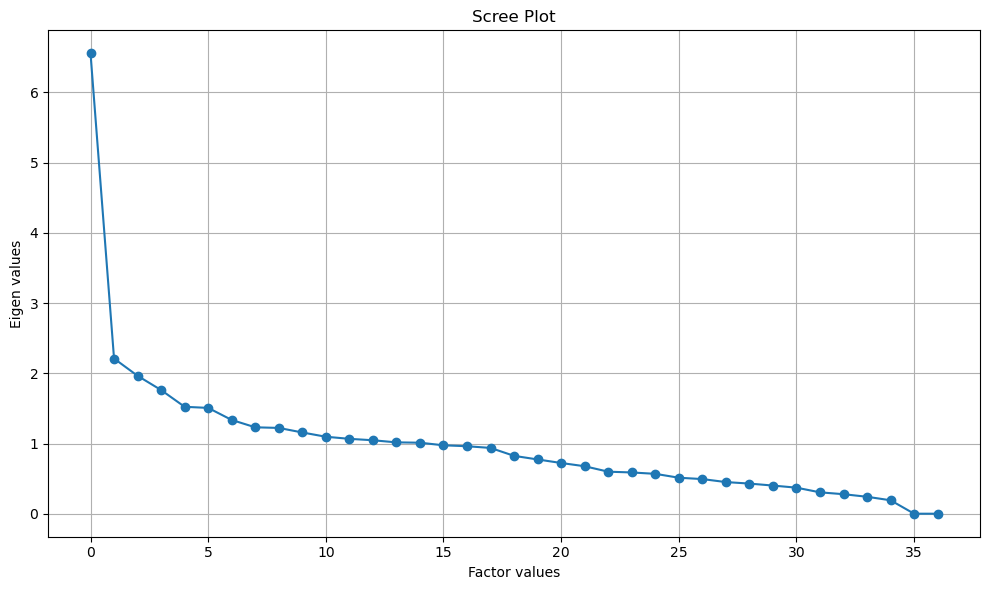

In [33]:
fac = FactorAnalyzer(n_factors=data.shape[1], rotation='varimax')
fac.fit(data)

eigen_vals, eigen_vecs = fac.get_eigenvalues()
fac_vals = np.arange(data.shape[1])

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(fac_vals, eigen_vals, marker='o')
plt.title('Scree Plot')
plt.grid()
plt.xlabel('Factor values')
plt.ylabel('Eigen values')
plt.tight_layout()
plt.show()

How many factors (or components) should we keep? 

Factor 1 is very high (≈ 6.5).
Factor 2 drops drastically (≈ 2.2).
Factor 3 drops a little bit (≈ 1.9). After Factor 3, the line becomes almost flat. Each new factor adds very little information. This means 2 or 3 factors would be a best choice.



In [34]:
fac = FactorAnalyzer(n_factors=data.shape[1], rotation='varimax')
fac.fit(data)

loadings = pd.DataFrame(fac.loadings_, index=data.columns)
loadings

,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
Income,0.679432,0.057876,0.013694,-0.006646,0.013077,0.150222,-0.040739,0.001689,0.141575,-0.010254,...,-0.028263,0.009862,0.292058,-0.011880,-0.001457,-3.574836e-03,-0.000849,0.0,0.0,0.0
Kidhome,-0.556023,-0.017420,0.016217,-0.002952,0.002843,-0.136047,-0.006147,-0.005156,-0.274203,-0.017215,...,0.090291,-0.033976,0.032145,0.009715,-0.007407,3.941698e-03,0.000730,0.0,0.0,0.0
Teenhome,-0.161882,0.015991,-0.004701,-0.025300,-0.013664,0.007070,-0.015641,0.012485,0.661554,-0.011954,...,-0.038136,-0.087607,0.064632,0.156583,-0.011232,1.287778e-02,-0.017559,0.0,0.0,0.0
Recency,0.012586,-0.007319,0.011495,0.007996,-0.013092,0.009220,-0.005917,0.004110,0.011964,0.000865,...,0.020102,0.000879,-0.001091,-0.000429,0.000557,-2.490739e-04,-0.000013,0.0,0.0,0.0
MntWines,0.634921,0.131361,-0.006911,0.000577,0.051737,0.399103,-0.070899,0.010637,0.116837,-0.007529,...,-0.058119,0.082781,-0.101692,-0.023645,0.094390,4.232367e-02,0.095858,0.0,0.0,0.0
MntFruits,0.727309,-0.063095,-0.005883,-0.002579,-0.036023,-0.052940,0.009692,0.015531,-0.069826,0.012257,...,0.029758,-0.082654,-0.035935,0.226613,0.033519,-4.484248e-04,0.003071,0.0,0.0,0.0
MntMeatProducts,0.816014,0.015757,0.008724,0.021786,0.010541,0.044392,-0.038313,-0.015364,-0.115380,-0.003025,...,-0.011701,0.015661,0.019973,-0.114973,-0.056208,-1.359567e-01,-0.017999,0.0,0.0,0.0
MntFishProducts,0.750081,-0.076399,0.023352,0.003384,-0.025834,-0.038694,0.047305,-0.006349,-0.052844,0.026078,...,-0.016348,-0.122219,-0.090382,-0.038810,0.020310,1.108761e-01,-0.011492,0.0,0.0,0.0
MntSweetProducts,0.700195,-0.071420,-0.008753,-0.001636,-0.044154,-0.027288,0.047366,0.004404,-0.061372,0.032638,...,-0.028312,-0.034508,-0.048997,0.021712,-0.010153,6.140004e-03,0.006843,0.0,0.0,0.0
MntGoldProds,0.492137,-0.116771,-0.005499,0.006419,-0.026933,0.018769,0.015964,0.008507,0.039932,0.020521,...,-0.069230,0.000715,-0.009501,0.006354,-0.006251,1.709401e-03,-0.000220,0.0,0.0,0.0


In [35]:
loadings.where(abs(loadings) > 0.5)

,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
Income,0.679432,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Kidhome,-0.556023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Teenhome,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.661554,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recency,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MntWines,0.634921,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MntFruits,0.727309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MntMeatProducts,0.816014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MntFishProducts,0.750081,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MntSweetProducts,0.700195,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MntGoldProds,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
fac_comm = pd.DataFrame(fac.get_communalities(), index=data.columns, columns=['Communalities'])
fac_comm

,Communalities
Income,0.678217
Kidhome,0.700725
Teenhome,0.683653
Recency,0.263231
MntWines,0.925483
MntFruits,0.654562
MntMeatProducts,0.813044
MntFishProducts,0.686372
MntSweetProducts,0.660339
MntGoldProds,0.574637
